# W&B Results Plotter - Custom Project

This notebook fetches Weights & Biases runs from a custom project, aggregates metrics across seeds, and plots mean with optional ranges (min/max, std, stderr). Features include:
- Custom label mapping for legend entries
- Publication-quality font size controls
- Consistent y-axis ranges for batch comparisons
- Automatic caching for faster subsequent runs
- PDF/PNG export options
- **Support for both "epoch" and "step" as x-axis** (configurable via `x_axis` parameter)

In [32]:
# Imports
import os

import numpy as np
import matplotlib.pyplot as plt
import wandb

import importlib

import wandb_plot_utils
importlib.reload(wandb_plot_utils)
from wandb_plot_utils import (
    plot_metric_over_epochs,
    save_current_figure,
    update_and_get_config_options,
    print_config_options,
    build_plot_filename,
    compute_global_metric_range,
)

In [33]:
# Project selection and available config options (run this first)
ENTITY = "haraghi"  # CHANGE THIS
PROJECT = "toydataset-nano-idnet-all"  # CHANGE THIS
OPTIONS_CACHE_DIR = "cache"
CONFIG_KEYS_TO_SCAN = None    # e.g., ["lr", "batch_size", "model_type"] or None for all keys
UPDATE_CONFIG_OPTIONS = False # set True to refresh from server
MAX_RUNS_TO_SCAN = None       # optional limit for speed

try:
    api = wandb.Api()
    options = update_and_get_config_options(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        cache_dir=OPTIONS_CACHE_DIR,
        force_refresh=UPDATE_CONFIG_OPTIONS,
        config_keys=CONFIG_KEYS_TO_SCAN,
        max_runs=MAX_RUNS_TO_SCAN,
    )
    print("Available config options with multiple values (from cache unless refreshed):")
    print_config_options(options, min_values=2)
except Exception as e:
    print(f"Error while retrieving config options: {e}")


Available config options with multiple values (from cache unless refreshed):
dataset:
  - {'common': {'data_root': 'toy_datasets/data/star8/variant_e450c505', 'test_root': 'toy_datasets/data/star8/test'}, 'dataset_name': 'dsec', 'num_voxel_bins': 5, 'representation_type': 'voxel', 'train': {'add_eigenvalues': False, 'add_filter_values': False, 'delta_t_ms': 20, 'do_not_save_preprocessed': True, 'downsample_ratio': 1, 'exclude_val': True, 'filter_size': 5, 'force_preprocess': True, 'horizontal_flip': 0.5, 'in_memory': True, 'load_gt': True, 'normalize_voxel': True, 'random_crop': None, 'seq': ['star8'], 'tau': 1000, 'use_all_seqs': True, 'vertical_flip': 0.1}, 'val': {'concat_seq': False, 'downsample_ratio': 1, 'seq': ['star8_test']}}
  - {'common': {'data_root': 'toy_datasets/data/star8/variant_e450c505', 'test_root': 'toy_datasets/data/star8/test'}, 'dataset_name': 'dsec', 'num_voxel_bins': 5, 'representation_type': 'voxel', 'train': {'add_eigenvalues': False, 'add_filter_values': Tru

In [34]:
# Configuration: choose filters and plotting options

# Filters can be scalars or lists. All list entries will be combined (cartesian product)
CONFIG_FILTER = {
    # CUSTOMIZE THESE TO YOUR PROJECT'S CONFIG KEYS
    # examples:
}

# Custom label mapping - CUSTOMIZE THIS
# Map internal config values to human-readable labels for the legend
LABEL_MAP = {

}

# Plot controls
METRIC = "nonrec/star8_test/final_prediction_nonseq/L2/avg"              # CHANGE THIS: metric key in W&B history
METRIC_LABEL = "L2 Error"  # CHANGE THIS: Short label for y-axis (if None, will use METRIC with formatting)
RANGE_TYPE = "std"               # "minmax" | "std" | "stderr" | "none"
INCLUDE_FILL = True
ALPHA = 0.25                     # transparency for fill_between
LINEWIDTH = 2.0
FIGSIZE = (8, 5)
GRID = True
SHOW_LEGEND = True

# X-axis control
X_AXIS = "_step"                 # CHANGE THIS: "_step" (default), "epoch", or any W&B history column name
X_LABEL = "Validation Step"                   # Optional custom x-axis label (e.g., "Training Step"); if None, auto-capitalizes X_AXIS

# Color control for consistent mapping by config key
COLOR_BY_KEY = None              # CHANGE THIS: set to your config key (e.g., "model_type")

# Font sizes for publication-quality figures
FONTSIZE_TITLE = 14
FONTSIZE_LABELS = 16
FONTSIZE_TICKS = 14
FONTSIZE_LEGEND = 14

# Caching controls
USE_CACHE = True                 # if True, load from cache when available
REFRESH_CACHE = False            # if True, refetch from W&B and overwrite cache
CACHE_DIR = "cache"

# Saving controls
SAVE_DIR = os.path.join("outputs", "toydataset_nano_idnet")  # where to save figures
SAVE_NAME = None                     # optional override; if None, name is auto-built from config
SAVE_PDF = True
SAVE_PNG = False
ADD_TIMESTAMP = False               # do not add time; filenames are configuration-specific

## Notes

- To compare multiple settings on the same plot, set list-valued entries in `CONFIG_FILTER` (e.g., `"lr": [1e-4, 5e-5]`). All combinations are plotted with separate lines.
- Choose `RANGE_TYPE` among `"minmax"`, `"std"`, `"stderr"`, or `"none"` for the shaded area around the mean. Toggle shading with `INCLUDE_FILL`.
- Set `SAVE_PDF=True` to export vector graphics; `SAVE_PNG=True` for raster. Files save to `SAVE_DIR` with the base `SAVE_NAME`.
- If you see "No runs" messages, adjust `CONFIG_FILTER` to match your W&B runs (entity/project must be correct).
- You can change `METRIC` to any history key logged in your runs (e.g., `"train_loss"`, `"accuracy"`).

### Axis Label Control

**X-Axis:**
- `X_AXIS`: Specifies which W&B history column to use (default: `"_step"`)
  - Common values: `"_step"`, `"epoch"`, or any custom column name
- `X_LABEL`: Custom label for x-axis (e.g., `"Training Iterations"`)
  - If `None`, auto-capitalizes `X_AXIS` (e.g., "_step" → "Step")

**Y-Axis:**
- `METRIC_LABEL`: Short, readable label for the metric (e.g., `"L1 Error"`)
  - If `None`, uses formatted `METRIC` name (replaces underscores, title case)
  - Useful when `METRIC` has a long W&B path like `"nonrec/star8_test/final_prediction_nonseq/L1/avg"`

**Important**: Make sure `X_AXIS` matches exactly what's logged in your W&B runs!

### Custom Legend Labels

Use the `LABEL_MAP` dictionary to provide human-readable labels for legend entries:

**For single varying key:**
```python
LABEL_MAP = {
    "model_v1": "Baseline Model",
    "model_v2": "Improved Model",
}
```

**For multiple varying keys (use exact label format):**
```python
LABEL_MAP = {
    "training_add_eigenvalues=False, training_add_filter_values=False": "Baseline",
    "training_add_eigenvalues=True, training_add_filter_values=False": "w/ Eigenvalues",
    "training_add_eigenvalues=False, training_add_filter_values=True": "w/ Density",
    "training_add_eigenvalues=True, training_add_filter_values=True": "w/ Both",
}
```

The mapping will automatically replace internal config combinations with your preferred labels in the legend.

### Publication-Quality Font Sizes
Adjust the following parameters for better readability in publications:
- `FONTSIZE_TITLE`: Title font size (default: 14)
- `FONTSIZE_LABELS`: X and Y axis labels font size (default: 16)
- `FONTSIZE_TICKS`: Tick labels font size (default: 14)
- `FONTSIZE_LEGEND`: Legend font size (default: 14)

For papers, consider using larger values like `FONTSIZE_TITLE=18`, `FONTSIZE_LABELS=16`, `FONTSIZE_TICKS=14`.

### Consistent Y-Axis for Batch Comparisons
The batch generation sections can use either:
1. **Computed global range**: `compute_global_metric_range()` scans all configs and finds min/max with margin
2. **Fixed range**: Set `FIXED_YLIM = (min, max)` when some values are outliers

This ensures all subfigures use the same scale for easy visual comparison.

## Batch generation: 6 figures for model dimensions

This section generates 6 figures with consistent y-axis ranges:
- **First 3 figures**: Fix `model_hidden_dim=4`, vary `model_input_dim = [4, 8, 16]`
  - Filenames: `h4_in4.pdf`, `h4_in8.pdf`, `h4_in16.pdf`
- **Last 3 figures**: Fix `model_input_dim=4`, vary `model_hidden_dim = [4, 8, 16]`
  - Filenames: `in4_h4.pdf`, `in4_h8.pdf`, `in4_h16.pdf`

Each figure plots 4 feature combinations based on:
- `training_add_eigenvalues`: True/False
- `training_add_filter_values`: True/False

**Filename suffix:** The `FILENAME_SUFFIX` variable automatically adds `RANGE_TYPE` to filenames when it's not the default "stderr". This prevents overwriting when experimenting with different settings:
- `stderr` (default): No suffix → `h4_in4.pdf`
- `std`: Adds suffix → `h4_in4_std.pdf`
- `minmax`: Adds suffix → `h4_in4_minmax.pdf`

**Important:** All 6 figures share the same y-axis range for easy comparison.

Using fixed y-axis range: [1, 9]
Range type: std

Generating figures with fixed model_hidden_dim=4
Saved: h4_in4_std -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


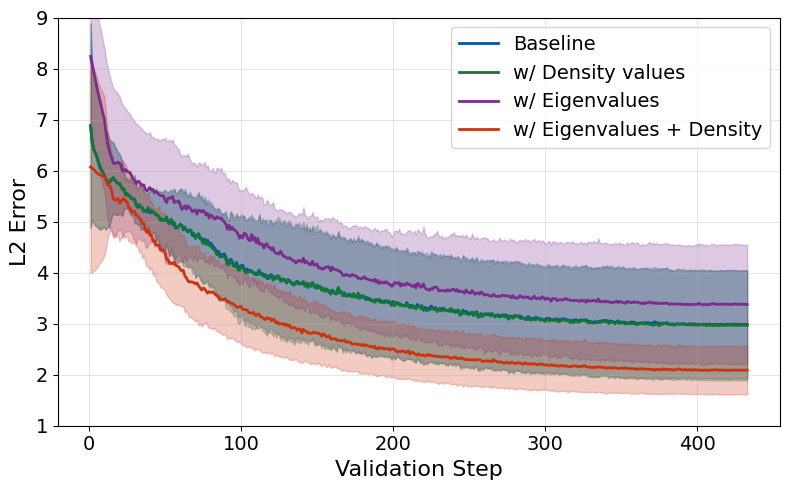

Saved: h4_in8_std -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


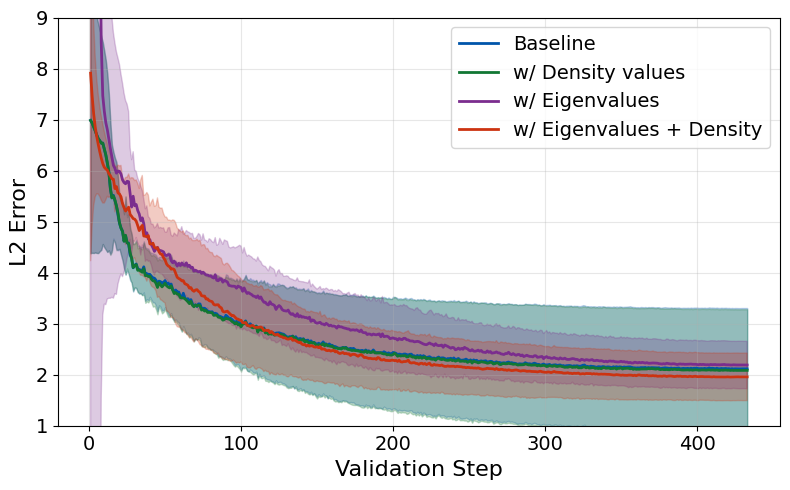

Saved: h4_in16_std -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


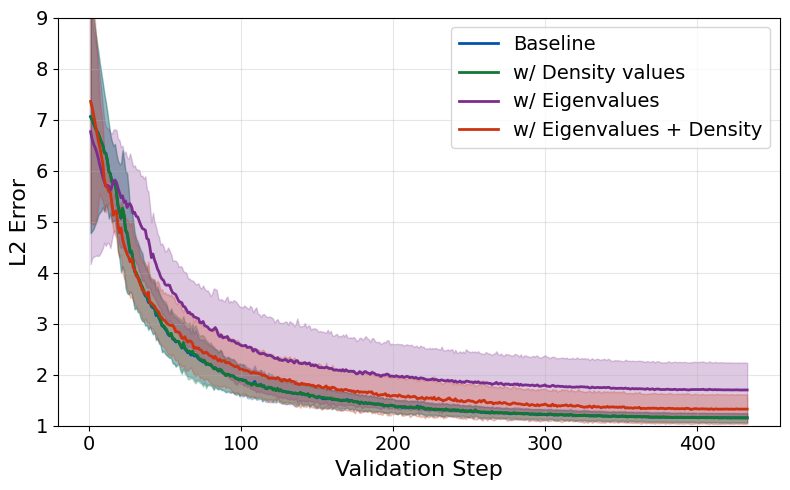


Generating figures with fixed model_input_dim=4
Saved: in4_h4_std -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


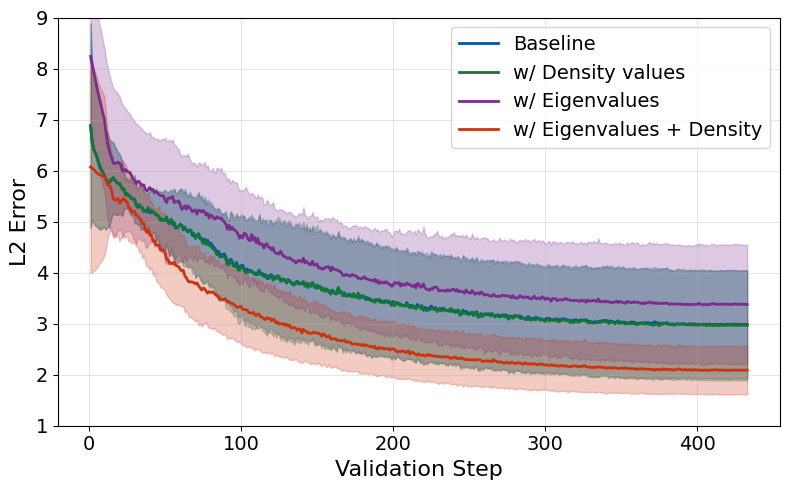

Saved: in4_h8_std -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


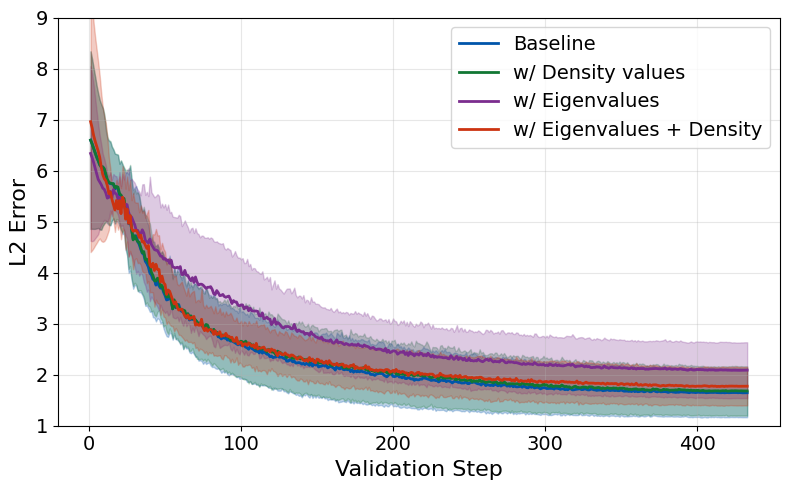

Saved: in4_h16_std -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


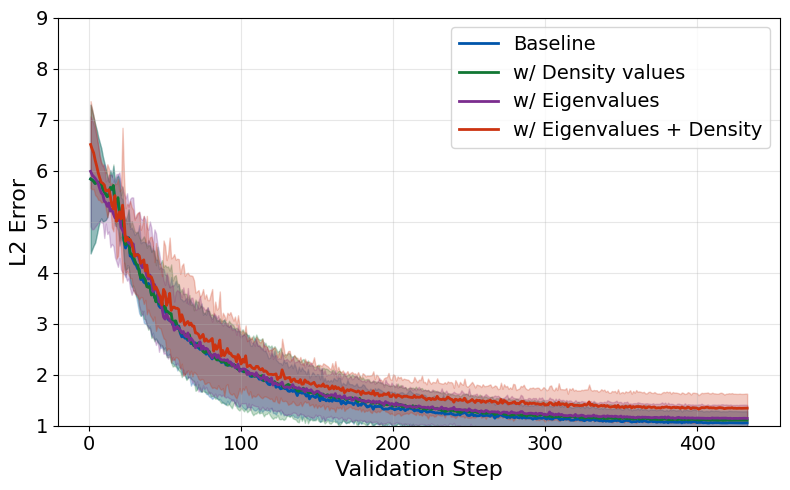


Batch generation complete!


In [35]:
# Batch generation: 6 figures for model dimensions and feature types

# Configuration for the batch
INPUT_DIMS = [4, 8, 16]   # model_input_dim values to test
HIDDEN_DIMS = [4, 8, 16]  # model_hidden_dim values to test

# Fixed y-axis range for all plots (instead of computing from data)
FIXED_YLIM = (1, 9)

# Feature labels mapping - must match the exact format generated by the plotting function
# When multiple keys vary, labels are formatted as: "key1=value1, key2=value2"
FEATURE_LABELS = {
    "training_add_eigenvalues=False, training_add_filter_values=False":     "Baseline",
    "training_add_eigenvalues=True, training_add_filter_values=False":      "w/ Eigenvalues",
    "training_add_eigenvalues=False, training_add_filter_values=True":      "w/ Density values",
    "training_add_eigenvalues=True, training_add_filter_values=True":       "w/ Eigenvalues + Density",
}

# Custom color palette - keys must match the FEATURE_LABELS values (the readable labels)
# These are the labels that will appear in the legend after transformation
COLOR_PALETTE_DICT = {
    "Baseline":                 "#0055AA",  # Deep blue
    "w/ Eigenvalues":           "#7B2D8E",  # Deep purple
    "w/ Density values":        "#117733",  # Deep green
    "w/ Eigenvalues + Density": "#CC3311",  # Deep red
}

# Filename suffix (optional) - add details like range type if you're experimenting
FILENAME_SUFFIX = f"_{RANGE_TYPE}" if RANGE_TYPE != "stderr" else ""

try:
    api = wandb.Api()
    
    print(f"Using fixed y-axis range: [{FIXED_YLIM[0]}, {FIXED_YLIM[1]}]")
    print(f"Range type: {RANGE_TYPE}")
    
    # Step 1: Generate first 3 figures (fixed hidden_dim=4, vary input_dim)
    print("\n" + "="*60)
    print("Generating figures with fixed model_hidden_dim=4")
    print("="*60)
    
    for input_dim in INPUT_DIMS:
        base_filter = {
            "model_hidden_dim": 4,
            "model_input_dim": input_dim,
            # Add any other fixed config keys here
        }
        
        # Add feature configs to the filter as lists for plotting all 4 combinations
        feature_filter = base_filter.copy()
        feature_filter["training_add_eigenvalues"] = [False, True]
        feature_filter["training_add_filter_values"] = [False, True]
        
        # Plot figure
        plot_metric_over_epochs(
            api=api,
            entity=ENTITY,
            project=PROJECT,
            base_filter=feature_filter,
            metric=METRIC,
            range_type=RANGE_TYPE,
            include_fill=INCLUDE_FILL,
            alpha=ALPHA,
            linewidth=LINEWIDTH,
            figsize=FIGSIZE,
            # title=f"model_hidden_dim=4, model_input_dim={input_dim}",
            title=None,
            grid=GRID,
            show_legend=SHOW_LEGEND,
            color_by_key=None,
            color_palette=COLOR_PALETTE_DICT,
            label_map=FEATURE_LABELS,  # Use feature labels
            fontsize_title=FONTSIZE_TITLE,
            fontsize_labels=FONTSIZE_LABELS,
            fontsize_ticks=FONTSIZE_TICKS,
            fontsize_legend=FONTSIZE_LEGEND,
            x_axis=X_AXIS,
            x_label=X_LABEL,
            y_label=METRIC_LABEL,  # Use custom y-axis label
            ylim=FIXED_YLIM,
            use_cache=USE_CACHE,
            refresh_cache=REFRESH_CACHE,
            cache_dir=CACHE_DIR,
        )
        
        # Short, meaningful filename with optional suffix for experimental settings
        filename = f"h4_in{input_dim}{FILENAME_SUFFIX}"
        if SAVE_PDF or SAVE_PNG:
            save_current_figure(
                save_dir=SAVE_DIR,
                save_name=filename,
                save_png=SAVE_PNG,
                save_pdf=SAVE_PDF,
                timestamp=False,
            )
            print(f"Saved: {filename} -> {os.path.abspath(SAVE_DIR)}")
        
        plt.show()
        plt.close()
    
    # Step 2: Generate last 3 figures (fixed input_dim=4, vary hidden_dim)
    print("\n" + "="*60)
    print("Generating figures with fixed model_input_dim=4")
    print("="*60)
    
    for hidden_dim in HIDDEN_DIMS:
        base_filter = {
            "model_hidden_dim": hidden_dim,
            "model_input_dim": 4,
            # Add any other fixed config keys here
        }
        
        # Add feature configs to the filter as lists for plotting all 4 combinations
        feature_filter = base_filter.copy()
        feature_filter["training_add_eigenvalues"] = [False, True]
        feature_filter["training_add_filter_values"] = [False, True]
        
        # Plot figure
        plot_metric_over_epochs(
            api=api,
            entity=ENTITY,
            project=PROJECT,
            base_filter=feature_filter,
            metric=METRIC,
            range_type=RANGE_TYPE,
            include_fill=INCLUDE_FILL,
            alpha=ALPHA,
            linewidth=LINEWIDTH,
            figsize=FIGSIZE,
            # title=f"model_input_dim=4, model_hidden_dim={hidden_dim}",
            title=None,
            grid=GRID,
            show_legend=SHOW_LEGEND,
            color_by_key=None,
            color_palette=COLOR_PALETTE_DICT,
            label_map=FEATURE_LABELS,  # Use feature labels
            fontsize_title=FONTSIZE_TITLE,
            fontsize_labels=FONTSIZE_LABELS,
            fontsize_ticks=FONTSIZE_TICKS,
            fontsize_legend=FONTSIZE_LEGEND,
            x_axis=X_AXIS,
            x_label=X_LABEL,
            y_label=METRIC_LABEL,  # Use custom y-axis label
            ylim=FIXED_YLIM,
            use_cache=USE_CACHE,
            refresh_cache=REFRESH_CACHE,
            cache_dir=CACHE_DIR,
        )
        
        # Short, meaningful filename with optional suffix for experimental settings
        filename = f"in4_h{hidden_dim}{FILENAME_SUFFIX}"
        if SAVE_PDF or SAVE_PNG:
            save_current_figure(
                save_dir=SAVE_DIR,
                save_name=filename,
                save_png=SAVE_PNG,
                save_pdf=SAVE_PDF,
                timestamp=False,
            )
            print(f"Saved: {filename} -> {os.path.abspath(SAVE_DIR)}")
        
        plt.show()
        plt.close()
        
    print("\n" + "="*60)
    print("Batch generation complete!")
    print("="*60)
    
except Exception as e:
    print(f"Batch generation error: {e}")

In [36]:
# Project selection and available config options (run this first)
ENTITY = "haraghi"
PROJECT = "toydataset-nano-idnet-all-textured"
OPTIONS_CACHE_DIR = "cache"
CONFIG_KEYS_TO_SCAN = None    # e.g., ["lr", "k", "feature_type"] or None for all keys
UPDATE_CONFIG_OPTIONS = False # set True to refresh from server
MAX_RUNS_TO_SCAN = None       # optional limit for speed

try:
    api = wandb.Api()
    options = update_and_get_config_options(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        cache_dir=OPTIONS_CACHE_DIR,
        force_refresh=UPDATE_CONFIG_OPTIONS,
        config_keys=CONFIG_KEYS_TO_SCAN,
        max_runs=MAX_RUNS_TO_SCAN,
    )
    print("Available config options with multiple values (from cache unless refreshed):")
    print_config_options(options, min_values=2)
except Exception as e:
    print(f"Error while retrieving config options: {e}")

Available config options with multiple values (from cache unless refreshed):
dataset:
  - {'common': {'data_root': 'toy_datasets/data/variant_0e580d25', 'test_root': 'toy_datasets/data/star8/test'}, 'dataset_name': 'dsec', 'num_voxel_bins': 5, 'representation_type': 'voxel', 'train': {'add_eigenvalues': False, 'add_filter_values': False, 'delta_t_ms': 20, 'do_not_save_preprocessed': True, 'downsample_ratio': 1, 'exclude_val': True, 'filter_size': 5, 'force_preprocess': True, 'horizontal_flip': 0.5, 'in_memory': True, 'load_gt': True, 'normalize_voxel': True, 'random_crop': None, 'seq': ['star8_textured'], 'tau': 1000, 'use_all_seqs': True, 'vertical_flip': 0.1}, 'val': {'concat_seq': False, 'downsample_ratio': 1, 'seq': ['star8_textured_test']}}
  - {'common': {'data_root': 'toy_datasets/data/variant_0e580d25', 'test_root': 'toy_datasets/data/star8/test'}, 'dataset_name': 'dsec', 'num_voxel_bins': 5, 'representation_type': 'voxel', 'train': {'add_eigenvalues': True, 'add_filter_values'

## Texture Comparison Experiment

Generate 3 figures (one per k value) comparing 10 different textures with 2 feature types (original and both).
Each texture gets a distinct shade within its feature type's color family.

In [37]:
# Generate color palette for texture experiment
# 5 textures with distinct colors, feature types distinguished by line style
import matplotlib.colors as mcolors

def generate_texture_colors():
    """Generate distinct colors for each texture."""
    
    # Texture filenames for mapping
    texture_files = [
        "data/dtd/images/flecked/flecked_0103.jpg",
        "data/dtd/images/honeycombed/honeycombed_0139.jpg",
        "data/dtd/images/spiralled/spiralled_0137.jpg",
        "data/dtd/images/stratified/stratified_0106.jpg",
        "data/dtd/images/woven/woven_0053.jpg",
    ]
    
    # Use a colormap with 5 distinct colors
    # Using tab10 colormap which has 5 distinct colors
    cmap = plt.cm.get_cmap('tab10')
    
    color_dict = {}
    for i, texture in enumerate(texture_files):
        color = mcolors.to_hex(cmap(i))
        color_dict[texture] = color
    
    return color_dict, texture_files

TEXTURE_COLOR_DICT, TEXTURE_FILES = generate_texture_colors()

# Create label map for textures (extract texture type from path)
TEXTURE_LABEL_MAP = {}
for texture in TEXTURE_FILES:
    # Extract texture type from path (e.g., "crosshatched")
    texture_name = texture.split("/")[-2]
    # Get filename number for uniqueness
    filename = texture.split("/")[-1].replace(".jpg", "").split("_")[-1]
    TEXTURE_LABEL_MAP[texture] = f"{texture_name}-{filename}"

# Line styles for feature types
FEATURE_LINE_STYLES = {
    "training_add_eigenvalues=False, training_add_filter_values=False":     "-",     # solid line
    "training_add_eigenvalues=True, training_add_filter_values=True":       "--",    # dashed line
}

print(f"Generated {len(TEXTURE_COLOR_DICT)} colors for textures")
print(f"Texture labels: {list(TEXTURE_LABEL_MAP.values())}")

Generated 5 colors for textures
Texture labels: ['flecked-0103', 'honeycombed-0139', 'spiralled-0137', 'stratified-0106', 'woven-0053']


/data/apptainer-tmp/ipykernel_92639/1248602551.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')



Generating figure for feature_type=original, ...
  Using base filter: {'model.hidden_dim': 4, 'model.input_dim': 4, 'dataset.fg_image_path': ['data/dtd/images/flecked/flecked_0103.jpg', 'data/dtd/images/honeycombed/honeycombed_0139.jpg', 'data/dtd/images/spiralled/spiralled_0137.jpg', 'data/dtd/images/stratified/stratified_0106.jpg', 'data/dtd/images/woven/woven_0053.jpg'], 'dataset.intensity_neg_threshold': 0.02, 'dataset.intensity_pos_threshold': 0.02, 'dataset.foreground_texture': 'image', 'training.add_eigenvalues': False, 'training.add_filter_values': False}
  Saved: texture_original.pdf -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


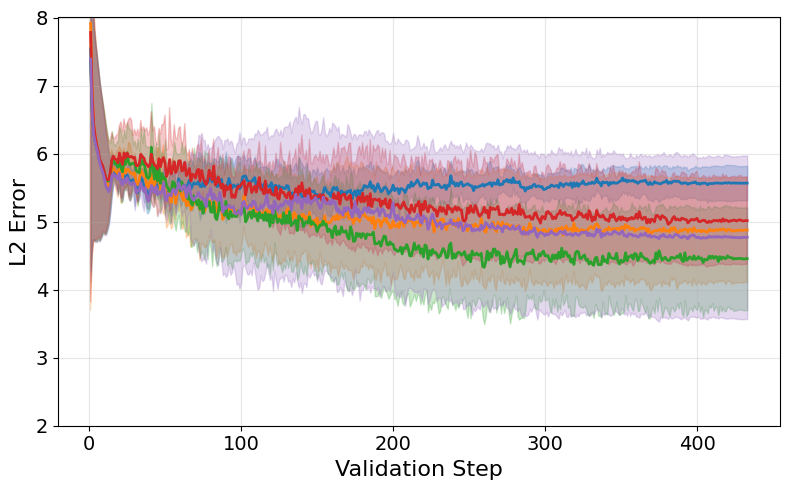


Generating figure for feature_type=both, ...
  Using base filter: {'model.hidden_dim': 4, 'model.input_dim': 4, 'dataset.fg_image_path': ['data/dtd/images/flecked/flecked_0103.jpg', 'data/dtd/images/honeycombed/honeycombed_0139.jpg', 'data/dtd/images/spiralled/spiralled_0137.jpg', 'data/dtd/images/stratified/stratified_0106.jpg', 'data/dtd/images/woven/woven_0053.jpg'], 'dataset.intensity_neg_threshold': 0.02, 'dataset.intensity_pos_threshold': 0.02, 'dataset.foreground_texture': 'image', 'training.add_eigenvalues': True, 'training.add_filter_values': True}
  Saved: texture_both.pdf -> /data/idnet/toy_datasets/outputs/toydataset_nano_idnet


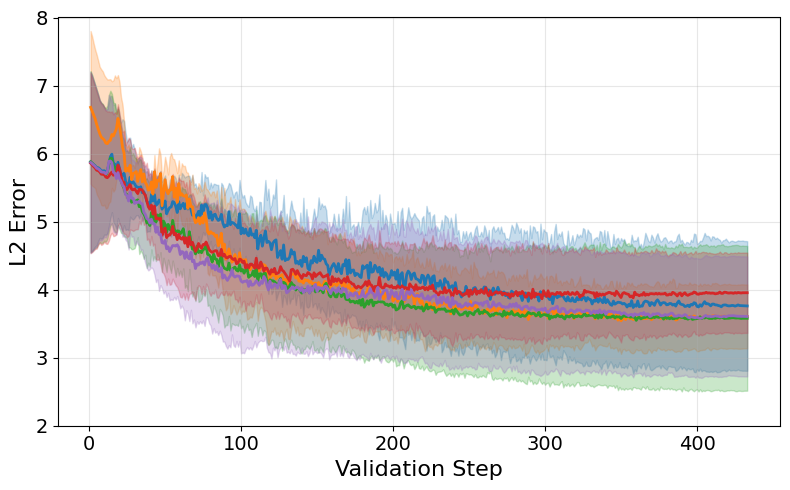

In [38]:
# Generate 2 figures for texture comparison
# Figure 1: Original (Baseline) with 5 textures
# Figure 2: Both (w/ Eigenvalues + Density) with 5 textures

# Plot controls

METRIC = "nonrec/star8_textured_test/final_prediction_nonseq/L2/avg"  # CHANGE THIS: metric key in W&B history
METRIC_LABEL = "L2 Error"  # CHANGE THIS: Short label for y-axis (if None, will use METRIC with formatting)
RANGE_TYPE = "std"  # "minmax" | "std" | "stderr" | "none"

SAVE_PDF = True

try:
    api = wandb.Api()
    
    # Generate one figure per feature type
    for feature_type in ["original", "both"]:
        print(f"\nGenerating figure for feature_type={feature_type}, ...")
        
        # Create base filter
        base_filter = {
            "model.hidden_dim": 4,
            "model.input_dim": 4,
            "dataset.fg_image_path": TEXTURE_FILES,
            "dataset.intensity_neg_threshold": 0.02,     
            "dataset.intensity_pos_threshold": 0.02,
            "dataset.foreground_texture": "image",
        }
        
        # Add feature-specific config
        if feature_type == "both":
            base_filter["training.add_eigenvalues"] = True
            base_filter["training.add_filter_values"] = True
        elif feature_type == "original":
            base_filter["training.add_eigenvalues"] = False
            base_filter["training.add_filter_values"] = False
        
        print(f"  Using base filter: {base_filter}")
        
        # Plot using plot_metric_over_epochs
        plot_metric_over_epochs(
            api=api,
            entity=ENTITY,
            project=PROJECT,
            base_filter=base_filter,
            metric=METRIC,
            range_type=RANGE_TYPE,
            include_fill=INCLUDE_FILL,
            alpha=ALPHA,
            linewidth=LINEWIDTH,
            figsize=FIGSIZE,
            title=None,  # No title
            grid=GRID,
            show_legend=False,  # No legend to avoid crowding
            color_by_key="dataset.fg_image_path",
            color_palette=TEXTURE_COLOR_DICT,
            label_map=None,  # No label mapping needed
            fontsize_title=FONTSIZE_TITLE,
            fontsize_labels=FONTSIZE_LABELS,
            fontsize_ticks=FONTSIZE_TICKS,
            fontsize_legend=FONTSIZE_LEGEND,
            ylim=(2.0, 8.0),
            x_axis=X_AXIS,
            x_label=X_LABEL,
            y_label=METRIC_LABEL,  # Use custom y-axis label
            use_cache=USE_CACHE,
            refresh_cache=REFRESH_CACHE,
            cache_dir=CACHE_DIR,
        )
        
        # Save figure
        filename = f"texture_{feature_type}"
        
        if SAVE_PDF or SAVE_PNG:
            save_current_figure(
                save_dir=SAVE_DIR,
                save_name=filename,
                save_png=SAVE_PNG,
                save_pdf=SAVE_PDF,
                timestamp=False,
            )
            print(f"  Saved: {filename}.pdf -> {os.path.abspath(SAVE_DIR)}")
        
        plt.show()
        plt.close()
        
except Exception as e:
    print(f"Error generating texture comparison figures: {e}")
    import traceback
    traceback.print_exc()

In [39]:
# Generate results table with final validation MSE loss
import numpy as np
from wandb_plot_utils import (
    fetch_runs,
    collect_metric_arrays,
    make_cache_key,
    get_cache_file,
    load_cached_arrays,
)

OUTPUT_DIR = os.path.join("outputs", "toydataset_nano_idnet")

try:
    api = wandb.Api()
    
    # Storage for results
    results = {}  # {texture: {feature_type: {'mean': val, 'std': val, 'runs': [...]}}}
    all_runs_data = {'original': [], 'both': []}  # Store all individual run values
    
    # Collect final validation loss for each texture and feature type
    for texture in TEXTURE_FILES:
        texture_name = TEXTURE_LABEL_MAP[texture]
        results[texture_name] = {}
        
        for feature_type in ["original", "both"]:
            config = {
                "model.hidden_dim": 4,
                "model.input_dim": 4,
                "dataset.fg_image_path": texture,
                "dataset.intensity_neg_threshold": 0.02,     
                "dataset.intensity_pos_threshold": 0.02,
                "dataset.foreground_texture": "image",
            }
        
            # Add feature-specific config
            if feature_type == "both":
                config["training.add_eigenvalues"] = True
                config["training.add_filter_values"] = True
            elif feature_type == "original":
                config["training.add_eigenvalues"] = False
                config["training.add_filter_values"] = False
            
            # Try to load from cache first
            cache_key = make_cache_key(ENTITY, PROJECT, config, METRIC)
            cache_path = get_cache_file(CACHE_DIR, cache_key)
            arr_epochs = load_cached_arrays(cache_path)
            
            if arr_epochs is not None:
                arr, epochs = arr_epochs
                # Get final epoch values for all seeds/runs
                final_values = arr[:, -1]  # last epoch for all seeds
                final_mean = np.nanmean(final_values)
                final_std = np.nanstd(final_values)
                results[texture_name][feature_type] = {
                    'mean': final_mean,
                    'std': final_std,
                    'runs': final_values
                }
                # Store all individual run values for overall calculation
                all_runs_data[feature_type].extend(final_values[~np.isnan(final_values)])
                print(f"Loaded from cache: {texture_name}, {feature_type}: {final_mean:.6f} ± {final_std:.6f}")
            else:
                # Fetch from W&B if not cached
                runs = fetch_runs(api, ENTITY, PROJECT, config)
                if len(runs) > 0:
                    out = collect_metric_arrays(runs, METRIC, x_axis="epoch")
                    if out is not None:
                        arr, epochs = out
                        final_values = arr[:, -1]
                        final_mean = np.nanmean(final_values)
                        final_std = np.nanstd(final_values)
                        results[texture_name][feature_type] = {
                            'mean': final_mean,
                            'std': final_std,
                            'runs': final_values
                        }
                        all_runs_data[feature_type].extend(final_values[~np.isnan(final_values)])
                        print(f"Fetched from W&B: {texture_name}, {feature_type}: {final_mean:.6f} ± {final_std:.6f}")
                    else:
                        print(f"No data: {texture_name}, {feature_type}")
                else:
                    print(f"No runs: {texture_name}, {feature_type}")
    
    # Calculate overall statistics (across all runs for all textures)
    overall_original_mean = np.mean(all_runs_data['original'])
    overall_original_std = np.std(all_runs_data['original'])
    overall_both_mean = np.mean(all_runs_data['both'])
    overall_both_std = np.std(all_runs_data['both'])
    overall_improvement = overall_original_mean - overall_both_mean  # Difference, not percentage
    overall_improvement_pct = (overall_improvement / overall_original_mean) * 100  # Percentage
    
    # Build tables
    texture_names = list(results.keys())
    
    # Markdown table
    md_lines = []
    md_lines.append("| Feature Type | " + " | ".join(texture_names) + " | Overall (Mean ± Std) |")
    md_lines.append("|" + "-" * 14 + "|" + "|".join(["-" * (len(t) + 2) for t in texture_names]) + "| " + "-" * 22 + "|")
    
    # Original row
    orig_row = "| Original | "
    orig_row += " | ".join([f"{results[t]['original']['mean']:.4f} ± {results[t]['original']['std']:.4f}" for t in texture_names])
    orig_row += f" | {overall_original_mean:.4f} ± {overall_original_std:.4f} |"
    md_lines.append(orig_row)
    
    # Both row
    both_row = "| Both | "
    both_row += " | ".join([f"{results[t]['both']['mean']:.4f} ± {results[t]['both']['std']:.4f}" for t in texture_names])
    both_row += f" | {overall_both_mean:.4f} ± {overall_both_std:.4f} |"
    md_lines.append(both_row)
    
    # Improvement row (with percentage in parentheses before difference)
    improve_row = "| Improvement | "
    improvements = []
    improvement_pcts = []
    for t in texture_names:
        improvement = results[t]['original']['mean'] - results[t]['both']['mean']
        improvement_pct = (improvement / results[t]['original']['mean']) * 100
        improvements.append(improvement)
        improvement_pcts.append(improvement_pct)
        improve_row += f"({improvement_pct:.2f}%) {improvement:.4f} | "
    improve_row += f"({overall_improvement_pct:.2f}%) {overall_improvement:.4f} |"
    md_lines.append(improve_row)
    
    md_table = "\n".join(md_lines)
    
    # LaTeX table
    latex_lines = []
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append("\\caption{Final Validation MSE Loss for Different Textures (k=50)}")
    latex_lines.append("\\label{tab:texture_results}")
    
    # Build column specification
    num_cols = len(texture_names) + 2  # textures + feature type + overall
    col_spec = "l" + "c" * (num_cols - 1)
    latex_lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    latex_lines.append("\\hline")
    
    # Header
    header = "Feature Type & " + " & ".join(texture_names) + " & Overall (Mean $\\pm$ Std) \\\\"
    latex_lines.append(header)
    latex_lines.append("\\hline")
    
    # Original row
    orig_latex = "Original & "
    orig_latex += " & ".join([f"${results[t]['original']['mean']:.4f} \\pm {results[t]['original']['std']:.4f}$" for t in texture_names])
    orig_latex += f" & ${overall_original_mean:.4f} \\pm {overall_original_std:.4f}$ \\\\"
    latex_lines.append(orig_latex)
    
    # Both row
    both_latex = "Both & "
    both_latex += " & ".join([f"${results[t]['both']['mean']:.4f} \\pm {results[t]['both']['std']:.4f}$" for t in texture_names])
    both_latex += f" & ${overall_both_mean:.4f} \\pm {overall_both_std:.4f}$ \\\\"
    latex_lines.append(both_latex)
    
    # Improvement row (with percentage in parentheses)
    improve_latex = "Improvement & "
    improve_latex += " & ".join([f"({pct:.2f}\\%) {imp:.4f}" for pct, imp in zip(improvement_pcts, improvements)])
    improve_latex += f" & ({overall_improvement_pct:.2f}\\%) {overall_improvement:.4f} \\\\"
    latex_lines.append(improve_latex)
    
    latex_lines.append("\\hline")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")
    
    latex_table = "\n".join(latex_lines)
    
    # Save tables
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    md_file = os.path.join(OUTPUT_DIR, "texture_results.md")
    with open(md_file, "w") as f:
        f.write("# Texture Comparison Results (k=50)\n\n")
        f.write(md_table)
    print(f"\nMarkdown table saved to: {md_file}")
    
    latex_file = os.path.join(OUTPUT_DIR, "texture_results.tex")
    with open(latex_file, "w") as f:
        f.write(latex_table)
    print(f"LaTeX table saved to: {latex_file}")
    
    # Display markdown table
    print("\n" + "="*80)
    print("MARKDOWN TABLE:")
    print("="*80)
    print(md_table)
    
    print("\n" + "="*80)
    print("LATEX TABLE:")
    print("="*80)
    print(latex_table)
    
except Exception as e:
    print(f"Error generating results table: {e}")
    import traceback
    traceback.print_exc()

Loaded from cache: flecked-0103, original: 5.565862 ± 0.252261
Loaded from cache: flecked-0103, both: 3.760194 ± 0.952298
Loaded from cache: honeycombed-0139, original: 4.877005 ± 0.771711
Loaded from cache: honeycombed-0139, both: 3.606226 ± 0.469889
Loaded from cache: spiralled-0137, original: 4.455046 ± 0.755177
Loaded from cache: spiralled-0137, both: 3.578930 ± 1.064216
Loaded from cache: stratified-0106, original: 5.014292 ± 0.643310
Loaded from cache: stratified-0106, both: 3.954377 ± 0.590247
Loaded from cache: woven-0053, original: 4.769566 ± 1.201435
Loaded from cache: woven-0053, both: 3.605867 ± 0.881906

Markdown table saved to: outputs/toydataset_nano_idnet/texture_results.md
LaTeX table saved to: outputs/toydataset_nano_idnet/texture_results.tex

MARKDOWN TABLE:
| Feature Type | flecked-0103 | honeycombed-0139 | spiralled-0137 | stratified-0106 | woven-0053 | Overall (Mean ± Std) |
|--------------|--------------|------------------|----------------|-----------------|-----

## Inspect Cache Files

Use this section to check how many runs are stored in cached files.

In [40]:
import glob
import hashlib
import json

def inspect_cache_file(cache_path: str):
    """Inspect a single cache file and print information about it."""
    if not os.path.exists(cache_path):
        print(f"Cache file not found: {cache_path}")
        return
    
    try:
        data = np.load(cache_path, allow_pickle=True)
        arr = data["arr"]
        epochs = data["epochs"]
        
        print(f"\n{'='*60}")
        print(f"Cache file: {os.path.basename(cache_path)}")
        print(f"Full path: {cache_path}")
        print(f"{'='*60}")
        print(f"Number of runs cached: {arr.shape[0]}")
        print(f"Number of {X_AXIS} values: {arr.shape[1]}")
        print(f"{X_AXIS.capitalize()} range: {epochs[0]} to {epochs[-1]}")
        
        # Print per-run statistics
        print(f"\nPer-run statistics:")
        for i, run_data in enumerate(arr):
            valid_data = run_data[~np.isnan(run_data)]
            if len(valid_data) > 0:
                print(f"  Run {i+1}: {len(valid_data)} valid points, "
                      f"mean={valid_data.mean():.4f}, "
                      f"min={valid_data.min():.4f}, "
                      f"max={valid_data.max():.4f}")
            else:
                print(f"  Run {i+1}: No valid data")
        
        # Print aggregated statistics
        print(f"\nAggregated statistics across runs:")
        for epoch_idx in [0, len(epochs)//2, len(epochs)-1]:
            epoch_val = epochs[epoch_idx]
            epoch_data = arr[:, epoch_idx]
            valid = epoch_data[~np.isnan(epoch_data)]
            if len(valid) > 0:
                print(f"  {X_AXIS.capitalize()}={epoch_val}: "
                      f"{len(valid)} runs, mean={valid.mean():.4f}, std={valid.std():.4f}")
        
    except Exception as e:
        print(f"Error reading cache file: {e}")


def list_all_cache_files(cache_dir: str = "cache"):
    """List all cache files in the cache directory."""
    if not os.path.exists(cache_dir):
        print(f"Cache directory not found: {cache_dir}")
        return []
    
    cache_files = glob.glob(os.path.join(cache_dir, "*.npz"))
    
    if not cache_files:
        print(f"No cache files found in {cache_dir}")
        return []
    
    print(f"\nFound {len(cache_files)} cache file(s) in {cache_dir}:")
    for i, cf in enumerate(cache_files, 1):
        size_mb = os.path.getsize(cf) / (1024 * 1024)
        print(f"  {i}. {os.path.basename(cf)} ({size_mb:.2f} MB)")
    
    return cache_files


def inspect_cache_for_config(
    entity: str,
    project: str,
    config_filter: dict,
    metric: str,
    cache_dir: str = "cache"
):
    """Inspect the cache file for a specific configuration."""
    # Recreate the cache key
    payload = {"entity": entity, "project": project, "metric": metric, "config": config_filter}
    s = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    key = hashlib.sha1(s.encode("utf-8")).hexdigest()
    cache_path = os.path.join(cache_dir, f"{key}.npz")
    
    inspect_cache_file(cache_path)


# Example usage:
print("=" * 60)
print("CACHE INSPECTION TOOLS")
print("=" * 60)

# List all cache files
all_caches = list_all_cache_files(CACHE_DIR)

# Inspect a specific cache (uncomment and modify as needed)
# inspect_cache_for_config(
#     entity=ENTITY,
#     project=PROJECT,
#     config_filter=CONFIG_FILTER,
#     metric=METRIC,
#     cache_dir=CACHE_DIR
# )

# Or inspect by filename directly (uncomment and modify)
# if all_caches:
#     inspect_cache_file(all_caches[0])  # Inspect the first cache file

CACHE INSPECTION TOOLS

Found 193 cache file(s) in cache:
  1. 19839658d7ad91ea72a3aa2f77a9c729f33907a3.npz (0.02 MB)
  2. 932e5dd810321f2fb17ebbd5c378ea1ef9baca7d.npz (0.02 MB)
  3. 8f0e7d891bb5e535393e783ff12b689a93855c87.npz (0.03 MB)
  4. 05d36ad8a2029042bbb07991c15034d3f7a0fedd.npz (0.04 MB)
  5. 087fb357dbcc293bbcdc2448f251c3a204de5aae.npz (0.02 MB)
  6. 489f7251f95ec60a1b70f100607fba3f857c42c7.npz (0.02 MB)
  7. f0533f8afde986eb7cbd62f5b17bb3fa7b6d5173.npz (0.02 MB)
  8. c17437bfcb76eaef41ab5d14a44b65e4f7eef16d.npz (0.02 MB)
  9. a29b5c999ba37fad12e95dfd322b5c28119a032d.npz (0.02 MB)
  10. ac14329642616cfe5d6eb391e7e11c88c668c2b5.npz (0.02 MB)
  11. 5410a2a0c4c944eb0ef4900754a8490a284471e0.npz (0.01 MB)
  12. ae24891e9131c6660c995a1f4bd54602dd7bb655.npz (0.02 MB)
  13. fe7eb9c923672dd17f87f33566dd7f092c2fc700.npz (0.02 MB)
  14. bf9b1cf9f0952400bc9b8e20933ae60ce50737f6.npz (0.02 MB)
  15. 0152c9a9f95497325fcfee0477578402a8a9cc6d.npz (0.03 MB)
  16. bdac1f641a464a8a2794a265db9b8a